#EDA ksmc datasets

###import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


##Load the data



In [2]:
df=pd.read_csv("/content/ksmc_icu_registry_dataset.csv")
df.head()
print(df.shape)
print(df.columns.to_list())

(79000, 20)
['Patient_ID', 'Age', 'Gender', 'Nationality', 'Hospital_Name', 'ICU_Type', 'Admission_Date', 'Length_of_Stay_Days', 'Primary_Diagnosis_Group', 'Severity_Score', 'Comorbidities_Count', 'Ventilator_Used', 'Dialysis_Required', 'Number_of_Lab_Tests', 'Number_of_Radiology_Procedures', 'Total_Cost_SAR', 'Cost_Per_Day_SAR', 'Discharge_Status', 'Readmission_30days', 'Discharge_Date']


## Chek the data

In [3]:
df.head()

,Patient_ID,Age,Gender,Nationality,Hospital_Name,ICU_Type,Admission_Date,Length_of_Stay_Days,Primary_Diagnosis_Group,Severity_Score,Comorbidities_Count,Ventilator_Used,Dialysis_Required,Number_of_Lab_Tests,Number_of_Radiology_Procedures,Total_Cost_SAR,Cost_Per_Day_SAR,Discharge_Status,Readmission_30days,Discharge_Date
0,PT000001,51,Female,Saudi,King Fahad Medical City,Surgical ICU,5/2/2018 2:45,4,Neurological,7,2,No,No,17,6,63858.160050,8631.831461,Recovered,No,5/6/2018 2:45
1,PT000002,14,Female,Saudi,King Fahad Medical City,Cardiac ICU,8/14/2018 11:36,8,Cancer,7,3,Yes,No,22,1,5903.169304,6537.965008,Recovered,No,8/22/2018 11:36
2,PT000003,71,Female,Saudi,King Fahad Medical City,Medical ICU,10/6/2022 18:59,5,Cancer,15,2,No,No,32,8,32631.489850,7824.332133,Recovered,No,10/11/2022 18:59
3,PT000004,60,Male,Saudi,King Abdulaziz Medical City,Cardiac ICU,1/7/2020 12:43,8,Cancer,22,1,Yes,No,49,1,36323.613810,1399.695372,Recovered,No,1/15/2020 12:43
4,PT000005,20,Female,Saudi,King Fahad Medical City,Cardiac ICU,6/9/2020 10:07,3,Respiratory,23,2,Yes,No,48,3,63415.509260,6001.708781,Recovered,No,6/12/2020 10:07


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79000 entries, 0 to 78999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient_ID                      79000 non-null  object 
 1   Age                             79000 non-null  int64  
 2   Gender                          79000 non-null  object 
 3   Nationality                     79000 non-null  object 
 4   Hospital_Name                   79000 non-null  object 
 5   ICU_Type                        79000 non-null  object 
 6   Admission_Date                  79000 non-null  object 
 7   Length_of_Stay_Days             79000 non-null  int64  
 8   Primary_Diagnosis_Group         79000 non-null  object 
 9   Severity_Score                  79000 non-null  int64  
 10  Comorbidities_Count             79000 non-null  int64  
 11  Ventilator_Used                 79000 non-null  object 
 12  Dialysis_Required               

,Age,Length_of_Stay_Days,Severity_Score,Comorbidities_Count,Number_of_Lab_Tests,Number_of_Radiology_Procedures,Total_Cost_SAR,Cost_Per_Day_SAR
count,79000.000000,79000.000000,79000.000000,79000.000000,79000.000000,79000.00000,79000.000000,79000.000000
mean,44.471823,7.008418,12.499582,1.996886,26.975063,5.01900,49874.298361,7001.286571
std,26.052789,2.653434,6.917274,1.414130,12.989713,2.58225,19784.865848,2960.068955
min,0.000000,0.000000,1.000000,0.000000,5.000000,1.00000,5000.000000,500.000000
25%,22.000000,5.000000,7.000000,1.000000,16.000000,3.00000,36295.050290,4987.162699
50%,44.000000,7.000000,13.000000,2.000000,27.000000,5.00000,49783.111845,6982.979466
75%,67.000000,9.000000,19.000000,3.000000,38.000000,7.00000,63322.418955,9012.602513
max,89.000000,22.000000,24.000000,10.000000,49.000000,9.00000,136030.920000,20095.837600


In [5]:
cat_cols = ['Ventilator_Used', 'Dialysis_Required', 'Readmission_30days',
'Discharge_Status', 'Gender', 'Nationality']

for col in cat_cols:
  print(f"{col}: {df[col].unique()}")

Ventilator_Used: ['No' 'Yes']
Dialysis_Required: ['No' 'Yes']
Readmission_30days: ['No' 'Yes']
Discharge_Status: ['Recovered' 'Deceased' 'Transferred']
Gender: ['Female' 'Male']
Nationality: ['Saudi' 'Non-Saudi']


In [6]:
binary_cols = {
'Ventilator_Used': {'No': 0, 'Yes': 1},
'Dialysis_Required': {'No': 0, 'Yes': 1},
'Readmission_30days': {'No': 0, 'Yes': 1},
'Gender': {'Female': 0, 'Male': 1},
'Nationality': {'Non-Saudi': 0, 'Saudi': 1}
}

for col, mapping in binary_cols.items():
  df[col] = df[col].map(mapping)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Discharge_Status'] = le.fit_transform(df['Discharge_Status'])

In [7]:

print(df[['Ventilator_Used', 'Dialysis_Required', 'Readmission_30days',
          'Gender', 'Nationality', 'Discharge_Status']].dtypes)


Ventilator_Used       int64
Dialysis_Required     int64
Readmission_30days    int64
Gender                int64
Nationality           int64
Discharge_Status      int64
dtype: object


##Check Missing Value

In [8]:
df.isnull().sum()
print(df.dtypes)
#So there is no Missing

Patient_ID                         object
Age                                 int64
Gender                              int64
Nationality                         int64
Hospital_Name                      object
ICU_Type                           object
Admission_Date                     object
Length_of_Stay_Days                 int64
Primary_Diagnosis_Group            object
Severity_Score                      int64
Comorbidities_Count                 int64
Ventilator_Used                     int64
Dialysis_Required                   int64
Number_of_Lab_Tests                 int64
Number_of_Radiology_Procedures      int64
Total_Cost_SAR                    float64
Cost_Per_Day_SAR                  float64
Discharge_Status                    int64
Readmission_30days                  int64
Discharge_Date                     object
dtype: object


##Check duplicate Rows

In [9]:
print(df.duplicated().sum())

#there is no duplicate Rows

0


In [10]:
print(df.nunique())

Patient_ID                        79000
Age                                  90
Gender                                2
Nationality                           2
Hospital_Name                         4
ICU_Type                              4
Admission_Date                    78055
Length_of_Stay_Days                  23
Primary_Diagnosis_Group               8
Severity_Score                       24
Comorbidities_Count                  11
Ventilator_Used                       2
Dialysis_Required                     2
Number_of_Lab_Tests                  45
Number_of_Radiology_Procedures        9
Total_Cost_SAR                    78017
Cost_Per_Day_SAR                  77755
Discharge_Status                      3
Readmission_30days                    2
Discharge_Date                    78079
dtype: int64


##data distribution

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Nationality'}>,
        <Axes: title={'center': 'Length_of_Stay_Days'}>],
       [<Axes: title={'center': 'Severity_Score'}>,
        <Axes: title={'center': 'Comorbidities_Count'}>,
        <Axes: title={'center': 'Ventilator_Used'}>,
        <Axes: title={'center': 'Dialysis_Required'}>],
       [<Axes: title={'center': 'Number_of_Lab_Tests'}>,
        <Axes: title={'center': 'Number_of_Radiology_Procedures'}>,
        <Axes: title={'center': 'Total_Cost_SAR'}>,
        <Axes: title={'center': 'Cost_Per_Day_SAR'}>],
       [<Axes: title={'center': 'Discharge_Status'}>,
        <Axes: title={'center': 'Readmission_30days'}>, <Axes: >,
        <Axes: >]], dtype=object)

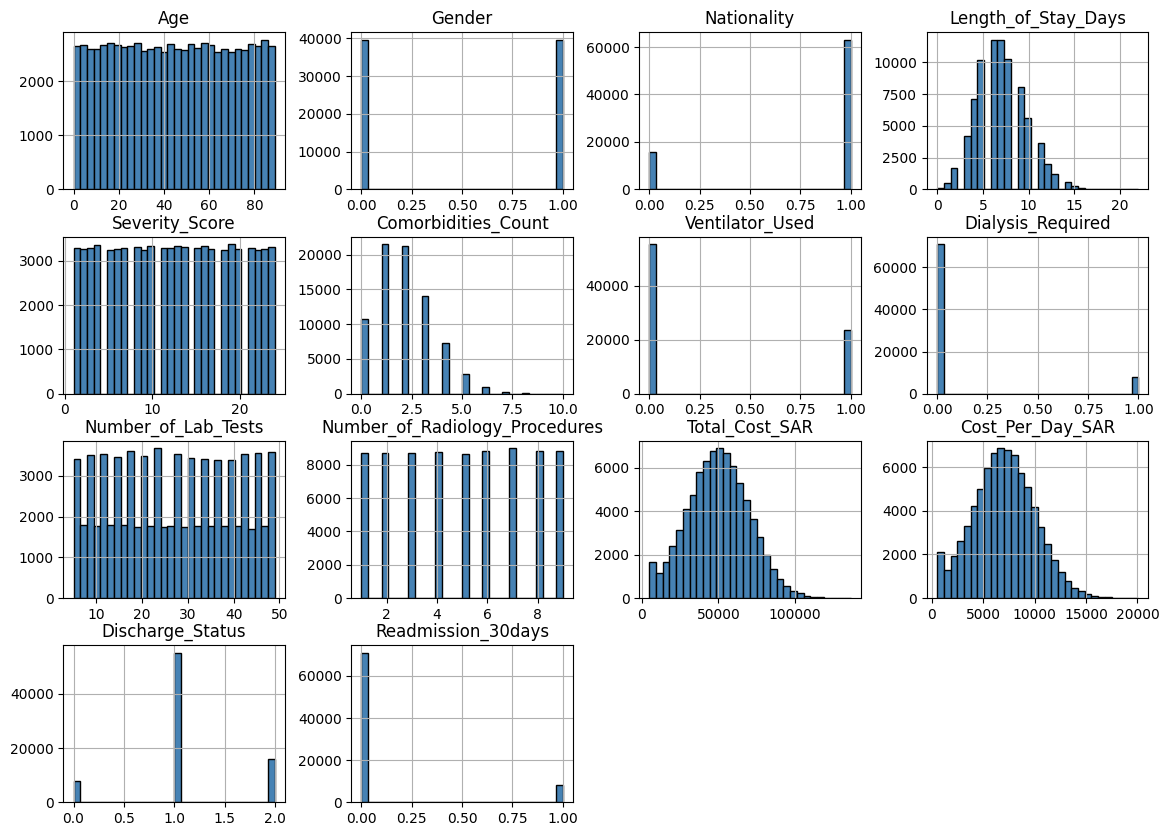

In [11]:
# using Histogram
num_c=df.select_dtypes(include=np.number).columns.tolist()
df[num_c].hist(figsize=(14,10),bins=30,color="steelblue",edgecolor="black")

##Check outliers

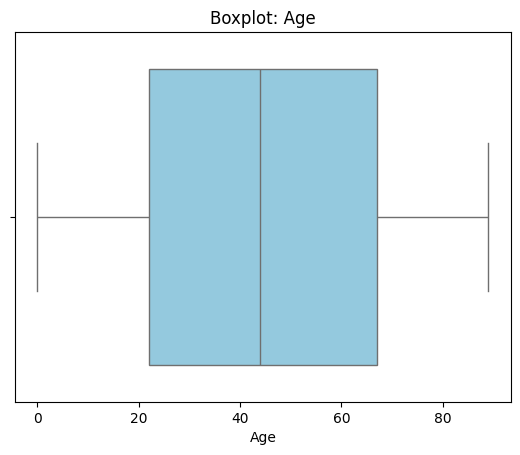

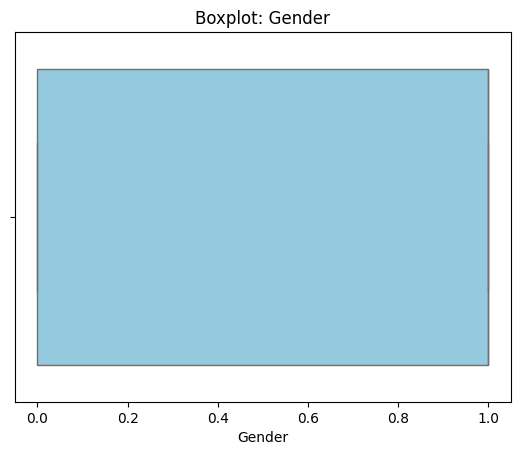

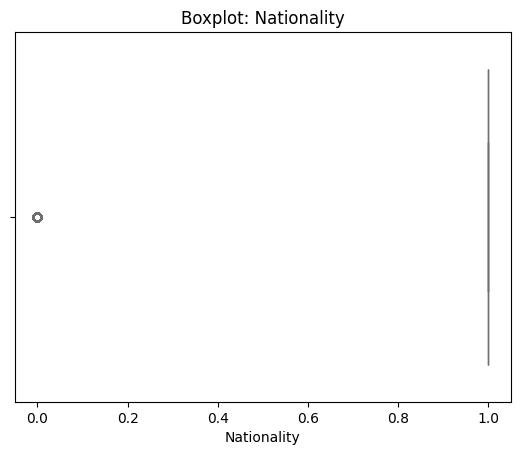

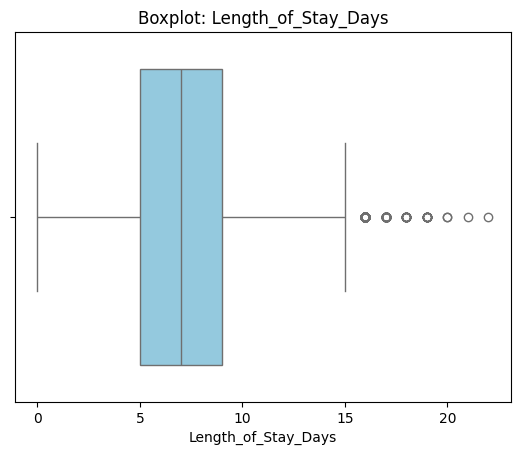

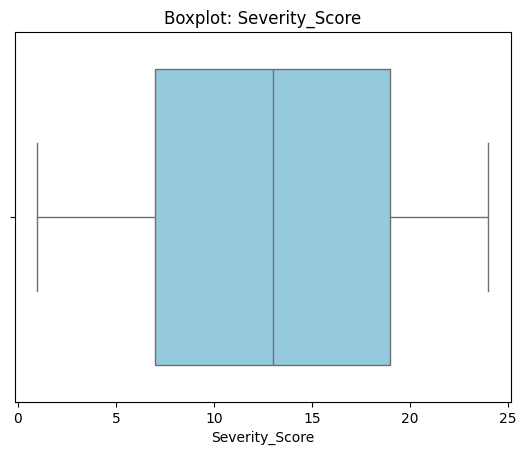

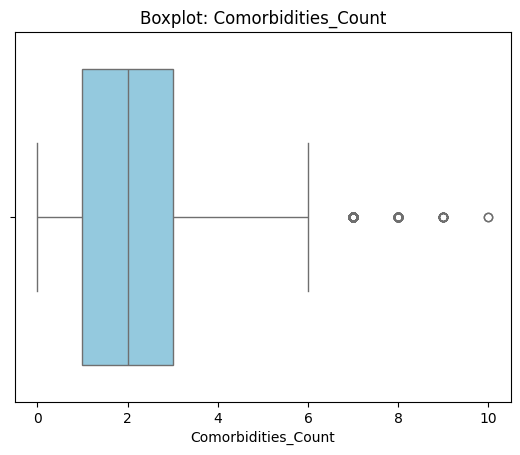

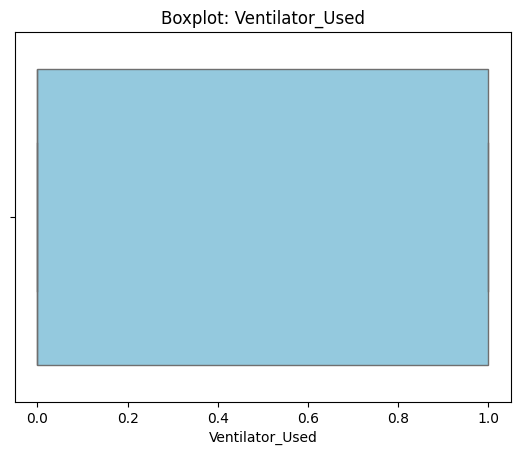

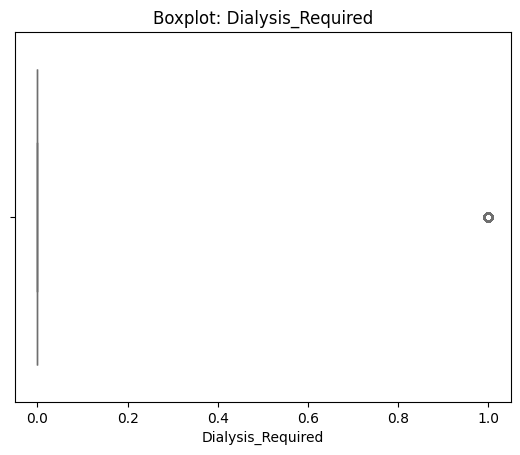

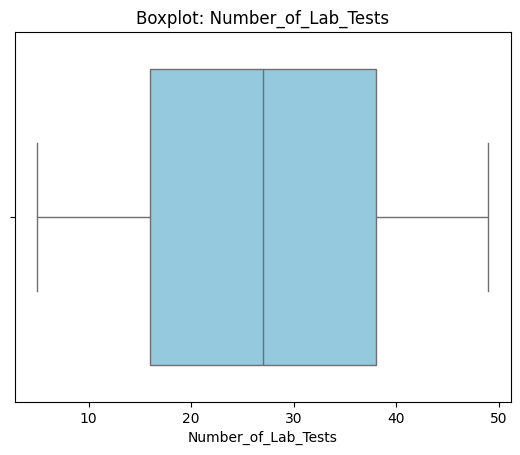

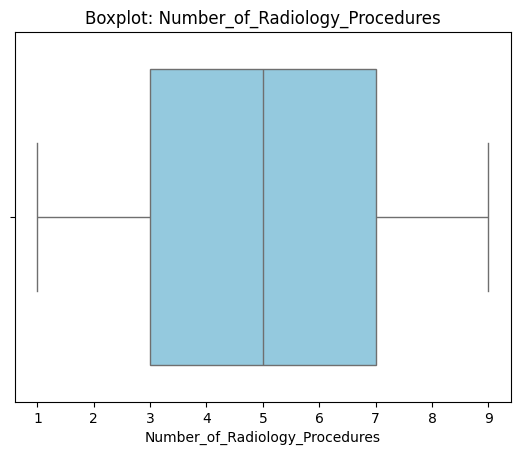

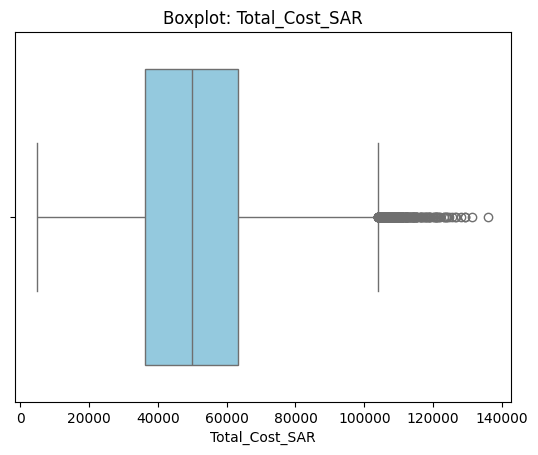

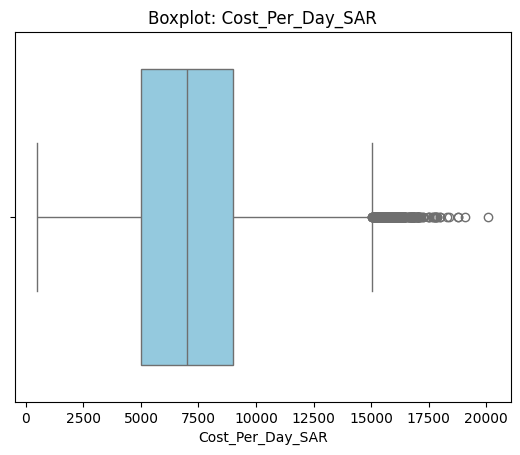

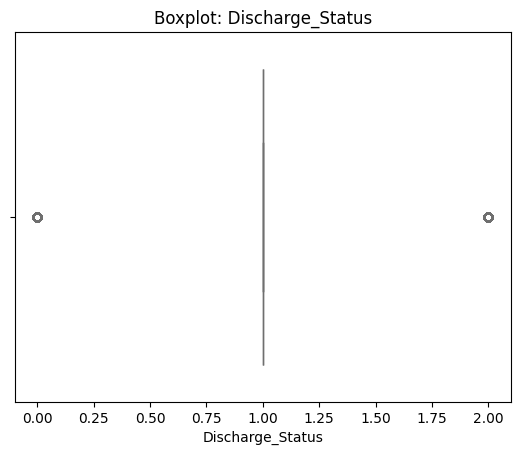

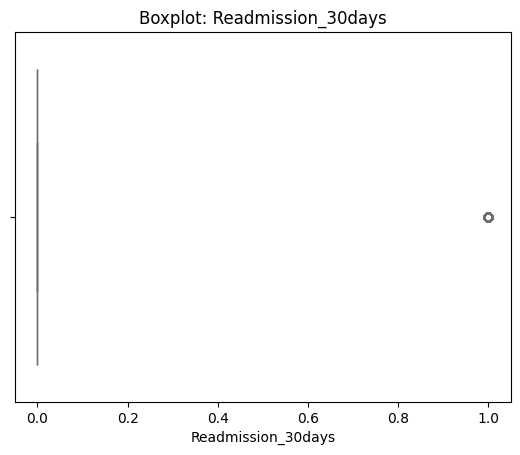

In [12]:
for col in num_c:
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f"Boxplot: {col}")
    plt.show()

#Corrleation Analysis

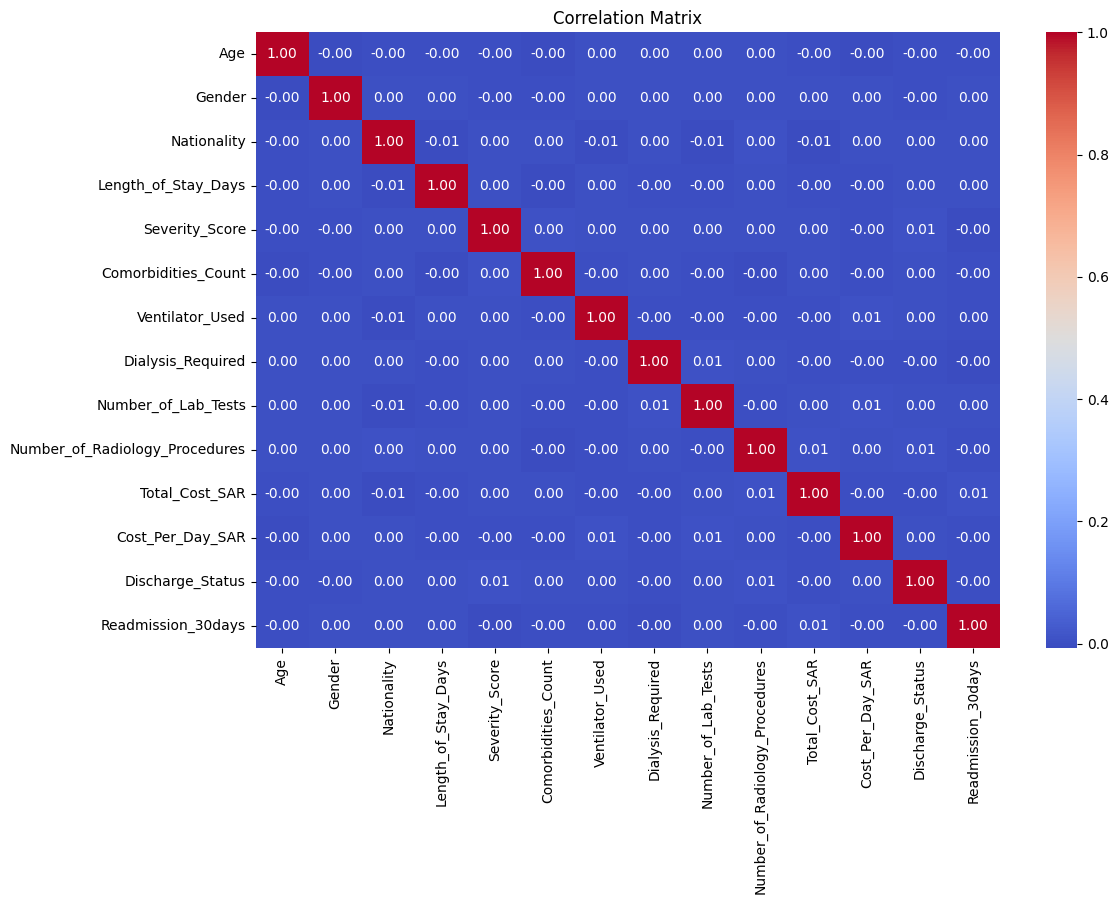

In [13]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

/tmp/ipykernel_623/2773926970.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x="Discharge_Status",y="Length_of_Stay_Days",data=df,palette="Set1")


<Axes: xlabel='Discharge_Status', ylabel='Length_of_Stay_Days'>

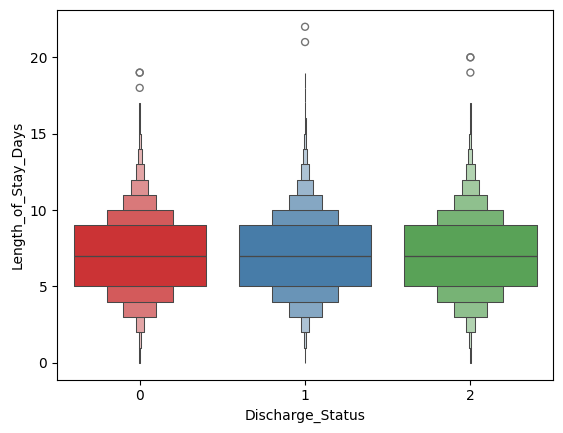

In [14]:
sns.boxenplot(x="Discharge_Status",y="Length_of_Stay_Days",data=df,palette="Set1")

#Features engineering

In [15]:
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

df['Admission_Month'] = df['Admission_Date'].dt.month
print(df[['Admission_Date', 'Admission_Month']].head())

       Admission_Date  Admission_Month
0 2018-05-02 02:45:00                5
1 2018-08-14 11:36:00                8
2 2022-10-06 18:59:00               10
3 2020-01-07 12:43:00                1
4 2020-06-09 10:07:00                6


/tmp/ipykernel_623/4214662989.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_counts.index, y=monthly_counts.values, palette='viridis')


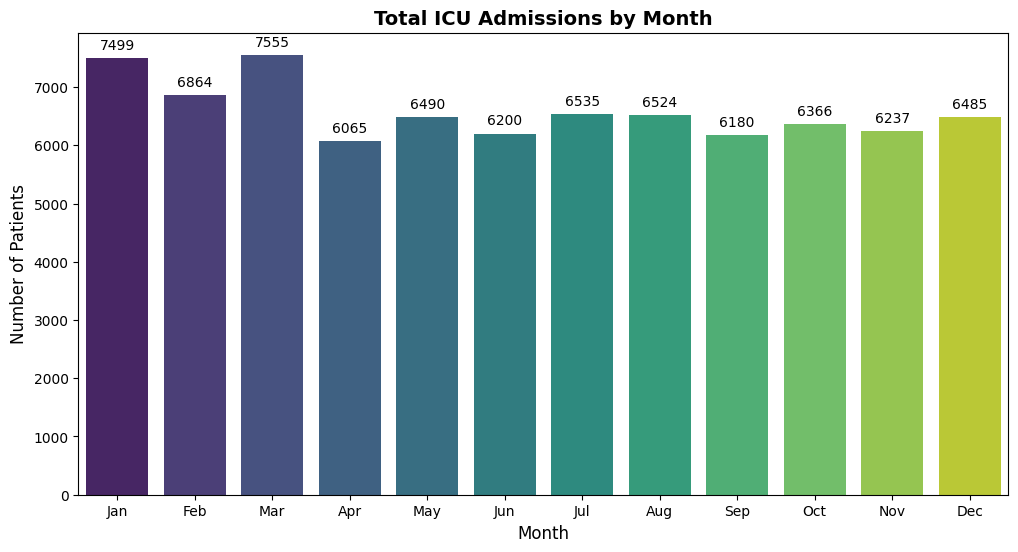

In [16]:

monthly_counts = df['Admission_Month'].value_counts().sort_index()

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, palette='viridis')

plt.title('Total ICU Admissions by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

plt.xticks(ticks=range(0, 12), labels=month_labels)

for index, value in enumerate(monthly_counts.values):
    plt.text(index, value + 100, str(value), ha='center', va='bottom', fontsize=10)

plt.show()

In [17]:
df['Calculated_Total_Cost'] = df['Length_of_Stay_Days'] * df['Cost_Per_Day_SAR']

print(df[['Length_of_Stay_Days', 'Cost_Per_Day_SAR', 'Calculated_Total_Cost']].head())

   Length_of_Stay_Days  Cost_Per_Day_SAR  Calculated_Total_Cost
0                    4       8631.831461           34527.325844
1                    8       6537.965008           52303.720064
2                    5       7824.332133           39121.660665
3                    8       1399.695372           11197.562976
4                    3       6001.708781           18005.126343


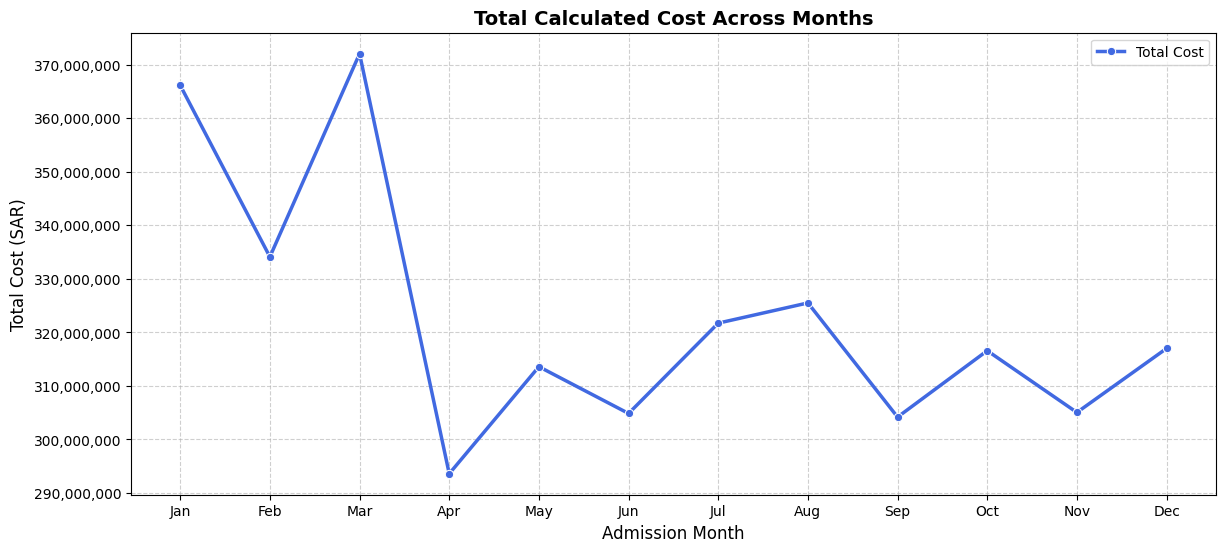

In [18]:


# 1. تجميع البيانات حسب الشهر وحساب مجموع التكلفة المحسوبة (Calculated_Total_Cost)
monthly_cost = df.groupby('Admission_Month')['Calculated_Total_Cost'].sum()
plt.figure(figsize=(14, 6))

sns.lineplot(x=monthly_cost.index, y=monthly_cost.values, marker='o', linewidth=2.5, color='royalblue', label='Total Cost')

plt.title('Total Calculated Cost Across Months', fontsize=14, fontweight='bold')
plt.xlabel('Admission Month', fontsize=12)
plt.ylabel('Total Cost (SAR)', fontsize=12)

plt.xticks(ticks=range(1, 13), labels=month_labels)

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()